In [104]:
import xgboost as xgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multiprocessing

# Load the California Housing dataset
california_housing = fetch_california_housing()
x, y = california_housing.data, california_housing.target


# Split the data into training and test sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.15)



In [181]:

bst = xgb.train(
    {
        'eta': 0.1,
        'max_depth': 5,
        'seed': 1994,
        'nthread': multiprocessing.cpu_count()//2
    },
    xgb.DMatrix(np.nan_to_num(xtrain, posinf=0.0, neginf=0.0), label=ytrain),
    num_boost_round=950,
    obj=custom_obj_3,
)


# Make predictions on the test set
ypred = bst.predict(xgb.DMatrix(xtest))

# Calculate the mean squared error and root mean squared error
mse = mean_squared_error(ytest, ypred)
print("MSE: %.2f" % mse)



MSE: 0.23


array([[<Axes: title={'center': '0'}>]], dtype=object)

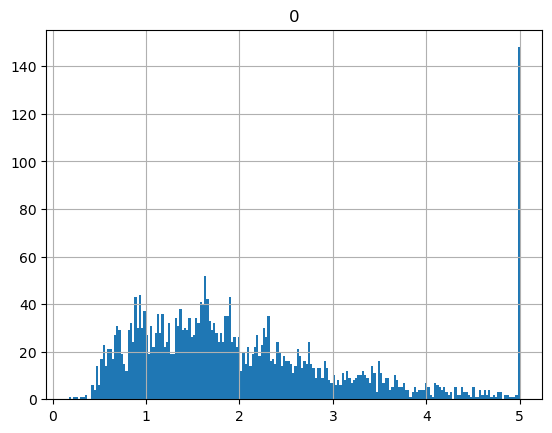

In [182]:
pd.DataFrame(ytest).hist(bins=200)

array([[<Axes: title={'center': '0'}>]], dtype=object)

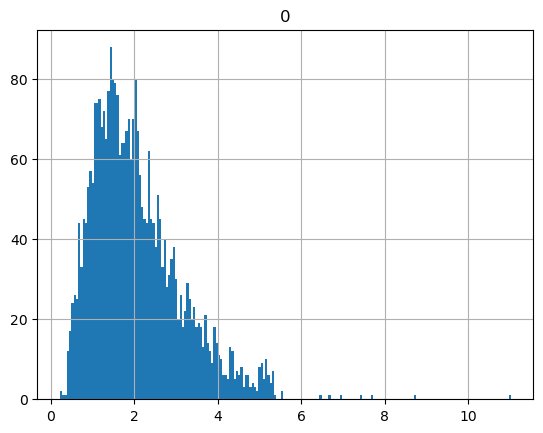

In [183]:
pd.DataFrame(ypred).hist(bins=200)

array([[<Axes: title={'center': '0'}>]], dtype=object)

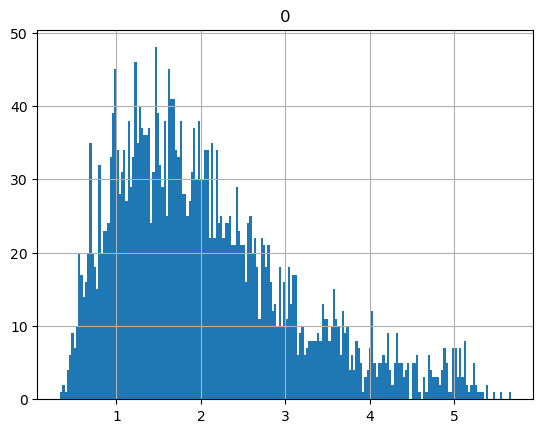

In [173]:
pd.DataFrame(ypred).hist(bins=200)

In [142]:
# def custom_obj(y_pred, dtrain):
#     # y_pred: 模型当前预测值（logit）
#     # dtrain: DMatrix，对象，含有真实值
#     y_true = dtrain.get_label()
    
#     maskpos   = np.where(y_true>4)
#     maskneg   = np.where(y_true<1)
#     y_pred_i  = y_pred[maskpos]
#     y_pred_j  = y_pred[maskneg]
#     y_pred_im = np.nanmean(y_pred[maskpos])
#     y_pred_jm = np.nanmean(y_pred[maskneg])
    
#     y_pred_k = y_pred[(~maskneg) & (~maskpos)]


#     grad_full = np.empty_like(y_pred)
# #     hess_full = np.empty_like(y_pred)
    
#     grad_full[maskpos] = -2*y_true[maskpos] - 0.5*y_pred_jm + 2.5*y_pred_i
#     grad_full[maskneg] = -2*y_true[maskneg] - 0.5*y_pred_im + 2.5*y_pred_j
#     grad_full[(~maskneg) & (~maskpos)] = -2.5*y_true[(~maskneg) & (~maskpos)] + 2.5*y_pred_k

#     return grad_full, np.full_like(y_pred, 2.5)


def custom_obj(y_pred, dtrain):
    # 获取真实标签
    y_true = dtrain.get_label()

    # 创建布尔掩码
    mask_pos = y_true > 4     # 强烈正样本
    mask_neg = y_true < 1     # 强烈负样本
    mask_mid = ~(mask_pos | mask_neg)  # 中性样本

    # 提取各类样本预测值
    y_pred_pos = y_pred[mask_pos]
    y_pred_neg = y_pred[mask_neg]
    y_pred_mid = y_pred[mask_mid]

    # 计算对方组的均值（注意避免全空）
    y_pred_pos_mean = np.nanmean(y_pred_pos) if y_pred_pos.size > 0 else 0.0
    y_pred_neg_mean = np.nanmean(y_pred_neg) if y_pred_neg.size > 0 else 0.0

    # 初始化梯度
    grad = np.zeros_like(y_pred)
    hess = np.full_like(y_pred, 1.5)  # 固定二阶导数，避免数值不稳定

    # 梯度计算（方向性 + 对比性）
    grad[mask_pos] = -2 * y_true[mask_pos] + 0.5 * y_pred_neg_mean + 1.5 * y_pred[mask_pos] if y_pred_neg.size > 0 else -1.5 * y_true[mask_pos] + 1.5 * y_pred[mask_pos]
    grad[mask_neg] = -2 * y_true[mask_neg] + 0.5 * y_pred_pos_mean + 1.5 * y_pred[mask_neg] if y_pred_pos.size > 0 else -1.5 * y_true[mask_neg] + 1.5 * y_pred[mask_neg]
    grad[mask_mid] = -1.5 * y_true[mask_mid] + 1.5 * y_pred[mask_mid]

    return grad, hess

In [180]:
from numpy import exp, log, cosh
def custom_obj_3(y_pred, dtrain):
    # 获取真实标签

    y_true = dtrain.get_label()

    alpha = 0.7
    reg = 0.0006
    # 创建布尔掩码
    mask_pos = y_true > 4     # 强烈正样本
    mask_neg = y_true < 1     # 强烈负样本
    mask_mid = ~(mask_pos | mask_neg)  # 中性样本

    # 提取各类样本预测值
    y_pred_pos = y_pred[mask_pos]
    y_pred_neg = y_pred[mask_neg]
    y_pred_mid = y_pred[mask_mid]

    # 计算对方组的均值（注意避免全空）
    y_pred_pos_mean = np.nanmean(y_pred_pos) if y_pred_pos.size > 0 else 0.0
    y_pred_neg_mean = np.nanmean(y_pred_neg) if y_pred_neg.size > 0 else 0.0

    
#     print(y_pred, y_true,'---', y_pred_pos.size, y_pred_neg.size)
    # 初始化梯度
    grad = np.zeros_like(y_pred)
    hess = np.zeros_like(y_pred)

    # 梯度计算（方向性 + 对比性）
    grad[mask_pos] = -2*alpha*(y_pred[mask_pos] - y_pred_neg_mean)/((y_pred[mask_pos] - y_pred_neg_mean)**2 + 1)**2 + 2*(1-alpha)*(y_pred[mask_pos] - y_true[mask_pos]) if y_pred_pos.size > 0 else 2*(y_pred[mask_pos] - y_true[mask_pos])
    grad[mask_neg] = -2*alpha*(y_pred[mask_neg] - y_pred_pos_mean)/((y_pred[mask_neg] - y_pred_pos_mean)**2 + 1)**2 + 2*(1-alpha)*(y_pred[mask_neg] - y_true[mask_neg]) if y_pred_neg.size > 0 else 2*(y_pred[mask_neg] - y_true[mask_neg])
    grad[mask_mid] = (2*y_pred[mask_mid] - 2*y_true[mask_mid])
    
    hess[mask_pos] = 2*alpha*(3*(y_pred[mask_pos] - y_pred_neg_mean)**2 - 1)/((y_pred[mask_pos] - y_pred_neg_mean)**2 + 1)**3 + 2*(1-alpha) if y_pred_pos.size > 0 else 2
    hess[mask_neg] = 2*alpha*(3*(y_pred[mask_neg] - y_pred_pos_mean)**2 - 1)/((y_pred[mask_neg] - y_pred_pos_mean)**2 + 1)**3 + 2*(1-alpha) if y_pred_neg.size > 0 else 2
    hess[mask_mid] = np.full_like(y_pred[mask_mid], 2.0)
    
#     print(grad, hess)
    return grad, hess


In [175]:
custom_obj_3(np.full(150, 0.5), xgb.DMatrix((np.random.rand(150) * 6 +1.).reshape(-1, 1), (np.random.rand(150) * 6 +1.).reshape(-1, 1)))

(array([ -8.64094708,  -2.04022503,  -6.31205533,  -5.69908524,
         -6.09337628, -10.27208722,  -3.31189013,  -6.66652536,
         -9.98862317,  -9.06401608,  -9.63804333,  -5.47329998,
         -7.07369855,  -1.9013052 ,  -6.52664426,  -4.43892384,
         -6.37480831,  -8.50979321,  -7.15854276,  -8.39626477,
         -6.20236635,  -6.61920178,  -3.05814648,  -5.36925888,
         -6.46894932,  -8.030668  ,  -8.70001385,  -3.34914017,
         -5.82236767,  -1.25845981,  -9.07154553,  -5.29283333,
         -3.1781373 ,  -9.97375653,  -1.35240412,  -2.43531203,
         -9.49422238,  -3.34603357,  -8.42935345,  -9.89132321,
         -5.7944917 ,  -6.89522457, -10.18464063,  -6.69873822,
         -4.60304451,  -8.37576459,  -9.98211377,  -7.37428067,
         -2.61372614,  -5.03460884,  -5.97744942,  -6.69025967,
         -3.23949814,  -6.26534512,  -6.39129496,  -6.66496976,
         -4.30719709,  -3.64925337,  -9.89313977,  -6.91845181,
         -9.20802548,  -1.10926771,  -6.

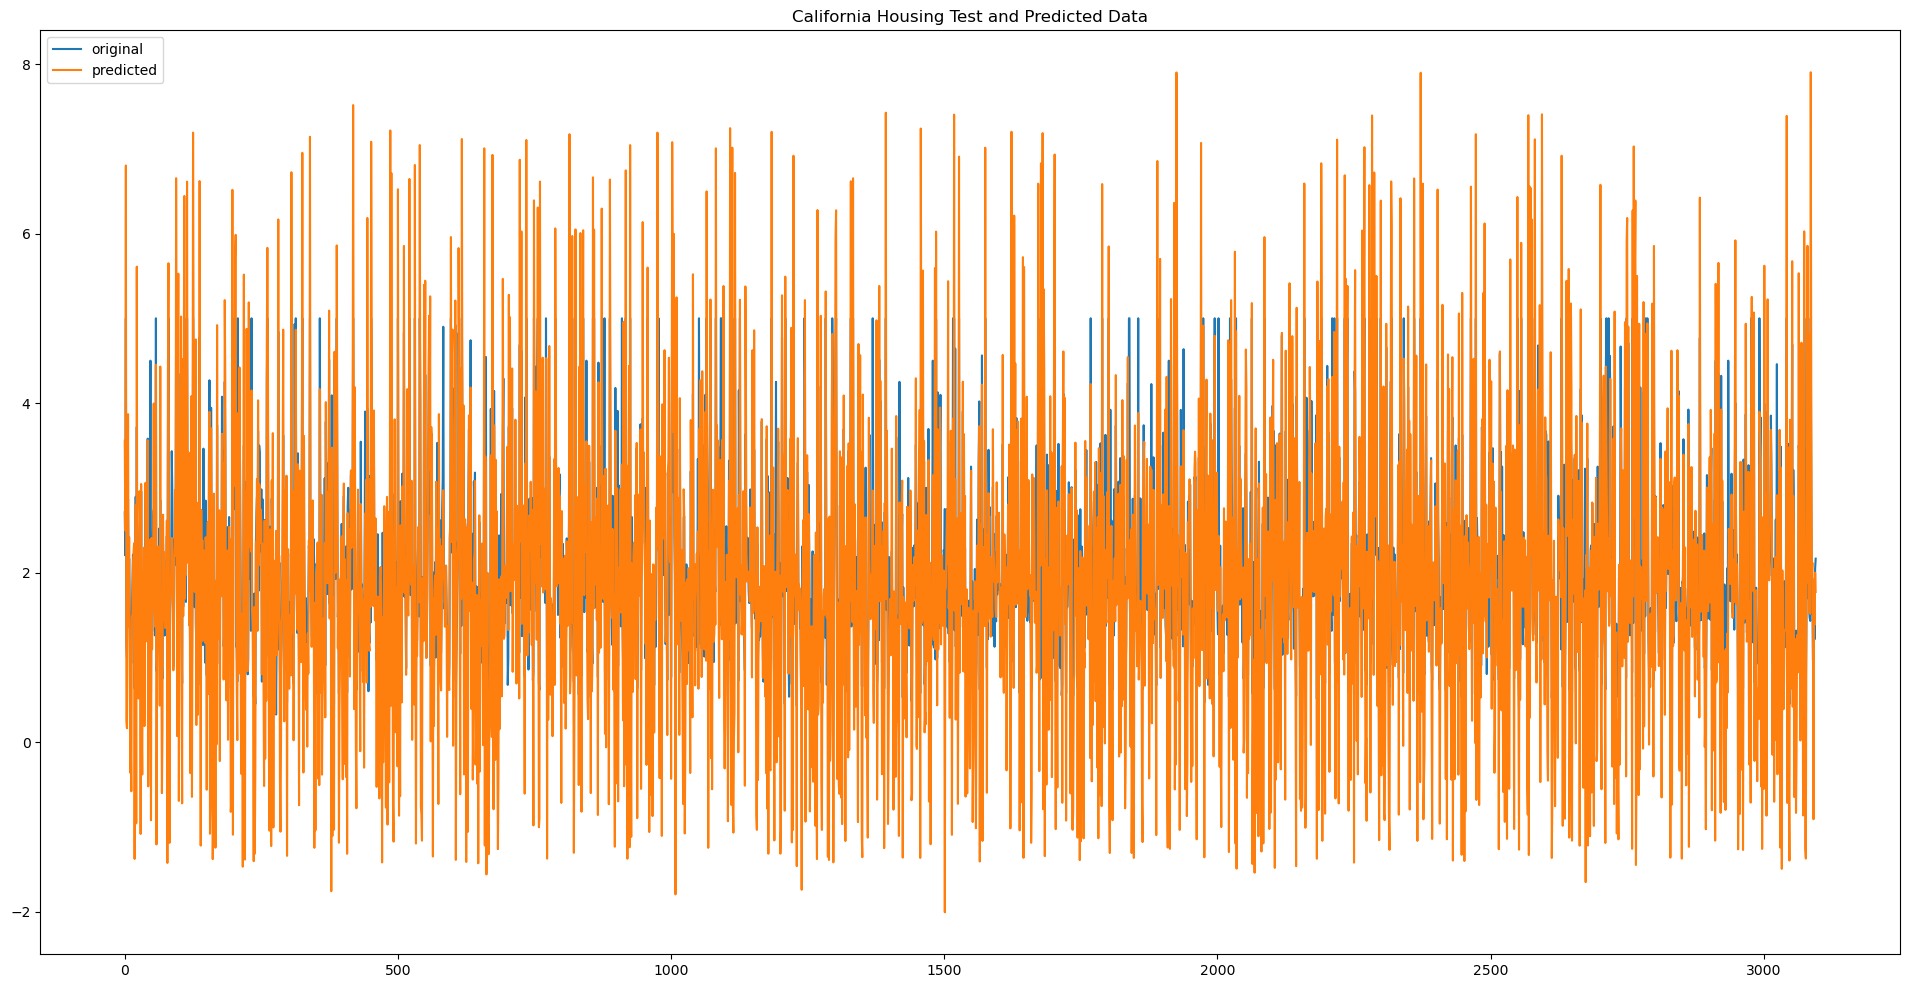

In [49]:
# Visualize the results
x_ax = range(len(ytest))
plt.figure(figsize=(24, 12))  
plt.plot(x_ax, ytest, label="original")
plt.plot(x_ax, ypred, label="predicted")
plt.title("California Housing Test and Predicted Data")
plt.legend()
plt.show()

In [ ]:
from numpy import exp, log, cosh
def custom_obj_2(y_pred, dtrain):
    # 获取真实标签

    y_true = dtrain.get_label()

    alpha = 0.5
    reg = 1
    # 创建布尔掩码
    mask_pos = y_true > 4     # 强烈正样本
    mask_neg = y_true < 1     # 强烈负样本
    mask_mid = ~(mask_pos | mask_neg)  # 中性样本

    # 提取各类样本预测值
    y_pred_pos = y_pred[mask_pos]
    y_pred_neg = y_pred[mask_neg]
    y_pred_mid = y_pred[mask_mid]

    # 计算对方组的均值（注意避免全空）
    y_pred_pos_mean = np.nanmean(y_pred_pos) if y_pred_pos.size > 0 else 0.0
    y_pred_neg_mean = np.nanmean(y_pred_neg) if y_pred_neg.size > 0 else 0.0

    
    print(y_pred, y_true,'---', y_pred_pos.size, y_pred_neg.size)
    # 初始化梯度
    grad = np.zeros_like(y_pred)
    hess = np.zeros_like(y_pred)

    # 梯度计算（方向性 + 对比性）
    grad[mask_pos] = -2*alpha*exp((reg + y_pred[mask_pos] - y_pred_neg_mean)**(-2))/((exp((reg + y_pred[mask_pos] - y_pred_neg_mean)**(-2)) + 1)*(reg + y_pred[mask_pos] - y_pred_neg_mean)**3) - 2*(alpha - 1)*(y_pred[mask_pos] - y_true[mask_pos]) if y_pred_pos.size > 0 else 2*(1-alpha)*(y_pred[mask_pos] - y_true[mask_pos])
    grad[mask_neg] = -2*alpha*exp((reg + y_pred[mask_neg] - y_pred_pos_mean)**(-2))/((exp((reg + y_pred[mask_neg] - y_pred_pos_mean)**(-2)) + 1)*(reg + y_pred[mask_neg] - y_pred_pos_mean)**3) - 2*(alpha - 1)*(y_pred[mask_neg] - y_true[mask_neg]) if y_pred_neg.size > 0 else 2*(1-alpha)*(y_pred[mask_neg] - y_true[mask_neg])
    grad[mask_mid] = (2*y_pred[mask_mid] - 2*y_true[mask_mid])
    
    hess[mask_pos] = (safe_div(alpha*(3*(exp((reg + y_pred[mask_pos]- y_pred_neg_mean)**(-2)) + 1)*(reg + y_pred[mask_pos]- y_pred_neg_mean)**2 + 2),(2*(reg + y_pred[mask_pos]- y_pred_neg_mean)**6*cosh(1/(2*(reg + y_pred[mask_pos]- y_pred_neg_mean)**2))**2)) + 2 - 2*alpha) if y_pred_pos.size > 0 else 2
    hess[mask_neg] = (safe_div(alpha*(3*(exp((reg + y_pred[mask_neg]- y_pred_pos_mean)**(-2)) + 1)*(reg + y_pred[mask_neg]- y_pred_pos_mean)**2 + 2),(2*(reg + y_pred[mask_neg]- y_pred_pos_mean)**6*cosh(1/(2*(reg + y_pred[mask_neg]- y_pred_pos_mean)**2))**2)) + 2 - 2*alpha) if y_pred_neg.size > 0 else 2
    hess[mask_mid] = np.full_like(y_pred[mask_mid], 2.0)
    
    print(grad, hess)
    return grad, hess
